# Regression Track - Hotel Booking Demand


**Problem statement.** Predict `adr` - the average daily rate a booking is
charged, in euros - from the attributes known at the time the booking is made.
A hotel that can price a booking before it is confirmed can flag under-priced
inventory and forecast revenue from the forward book.

**Dataset.** `data/hotel_bookings.csv`, 119,390 bookings × 32 columns, from
Antonio, Almeida & Nunes (2019), *Hotel booking demand datasets*,
Data in Brief 22:41–49.

**Notebook map** (rubric references in brackets):

| § | Contents | Rubric |
|---|---|---|
| 1 | Load & audit | A1 |
| 2 | Exploratory data analysis | A2, A3 |
| 3 | Cleaning | B1 |
| 4 | Feature engineering | B3 |
| 5 | Encoding, scaling & splitting | B2 |
| 6 | Ten regression algorithms | C1 |
| 7 | Comparative evaluation | C2 |
| 8 | Hyperparameter tuning | C3 |
| 9 | Diagnostic visualisation | C4 |
| 10 | Conclusion | - |

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Lasso/ElasticNet warn about the coordinate-descent iteration cap; we raise
# max_iter where it matters and do not want the notebook output buried.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA = "../data/hotel_bookings.csv"

## 1. Load & audit  *(A1)*

Before touching anything we record what arrived: shape, column types, how much
is missing, and the shape of the target.

In [2]:
df_raw = pd.read_csv(DATA)
print(f"rows: {df_raw.shape[0]:,}    columns: {df_raw.shape[1]}")
df_raw.head()

rows: 119,390    columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(),
})
audit

,dtype,missing,missing_%,unique
hotel,str,0,0.00,2
is_canceled,int64,0,0.00,2
lead_time,int64,0,0.00,479
arrival_date_year,int64,0,0.00,3
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
arrival_date_day_of_month,int64,0,0.00,31
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35
adults,int64,0,0.00,14


In [4]:
print("Target `adr` (average daily rate, EUR)")
print(df_raw["adr"].describe().round(2))
print(f"\nnegative values : {(df_raw['adr'] < 0).sum()}")
print(f"zero values     : {(df_raw['adr'] == 0).sum():,}")
print(f"above 1000      : {(df_raw['adr'] > 1000).sum()}")
print(f"\nexact duplicate rows: {df_raw.duplicated().sum():,}"
      f" ({df_raw.duplicated().mean() * 100:.1f}%)")

Target `adr` (average daily rate, EUR)
count    119390.00
mean        101.83
std          50.54
min          -6.38
25%          69.29
50%          94.58
75%         126.00
max        5400.00
Name: adr, dtype: float64

negative values : 1
zero values     : 1,959
above 1000      : 1



exact duplicate rows: 31,994 (26.8%)


**Observation.** Four columns carry missing values and they are missing for
four different reasons, so a single global fill would be wrong:

* `company` (94.3%) - almost never populated; the id is unusable but *whether a
  company was involved* is not.
* `agent` (13.7%) - a blank means the booking came in without a travel agent,
  which is information, not absence of it.
* `country` (0.4%) and `children` (4 rows) - genuine gaps, and small enough to
  fill without distorting anything.

The target is heavily right-skewed: the median is €94.6 but the maximum is
€5,400, and one booking is priced at −€6.4. There are also 1,959 bookings at
exactly €0 (complimentary rooms and staff stays) - those are real records, not
errors, so they stay.

The ~32k exact duplicates are addressed in §3.

## 2. Exploratory data analysis  *(A2, A3)*

### 2.1 Target distribution

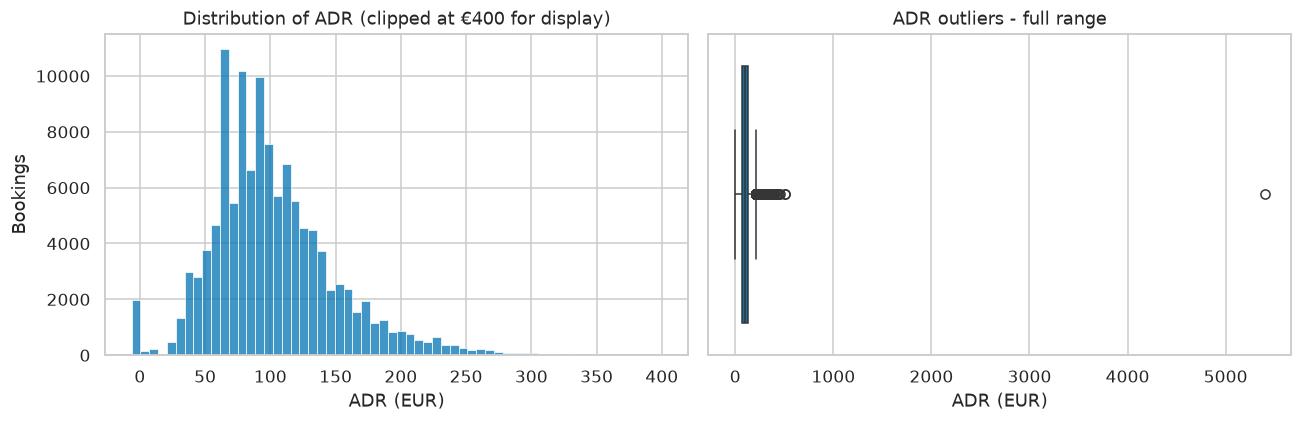

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw["adr"].clip(-10, 400), bins=60, ax=axes[0])
axes[0].set(title="Distribution of ADR (clipped at €400 for display)",
            xlabel="ADR (EUR)", ylabel="Bookings")
sns.boxplot(x=df_raw["adr"], ax=axes[1])
axes[1].set(title="ADR outliers - full range", xlabel="ADR (EUR)")
plt.tight_layout()
plt.show()

**Observation:** ADR is unimodal around €70-120 with a long right tail. The
box plot makes the case for treating the extreme tail: a single €5,400 booking
sits four times further out than the next-largest value, and squared-error
losses would let that one row dominate the fit.

### 2.2 Distributions of the numeric features

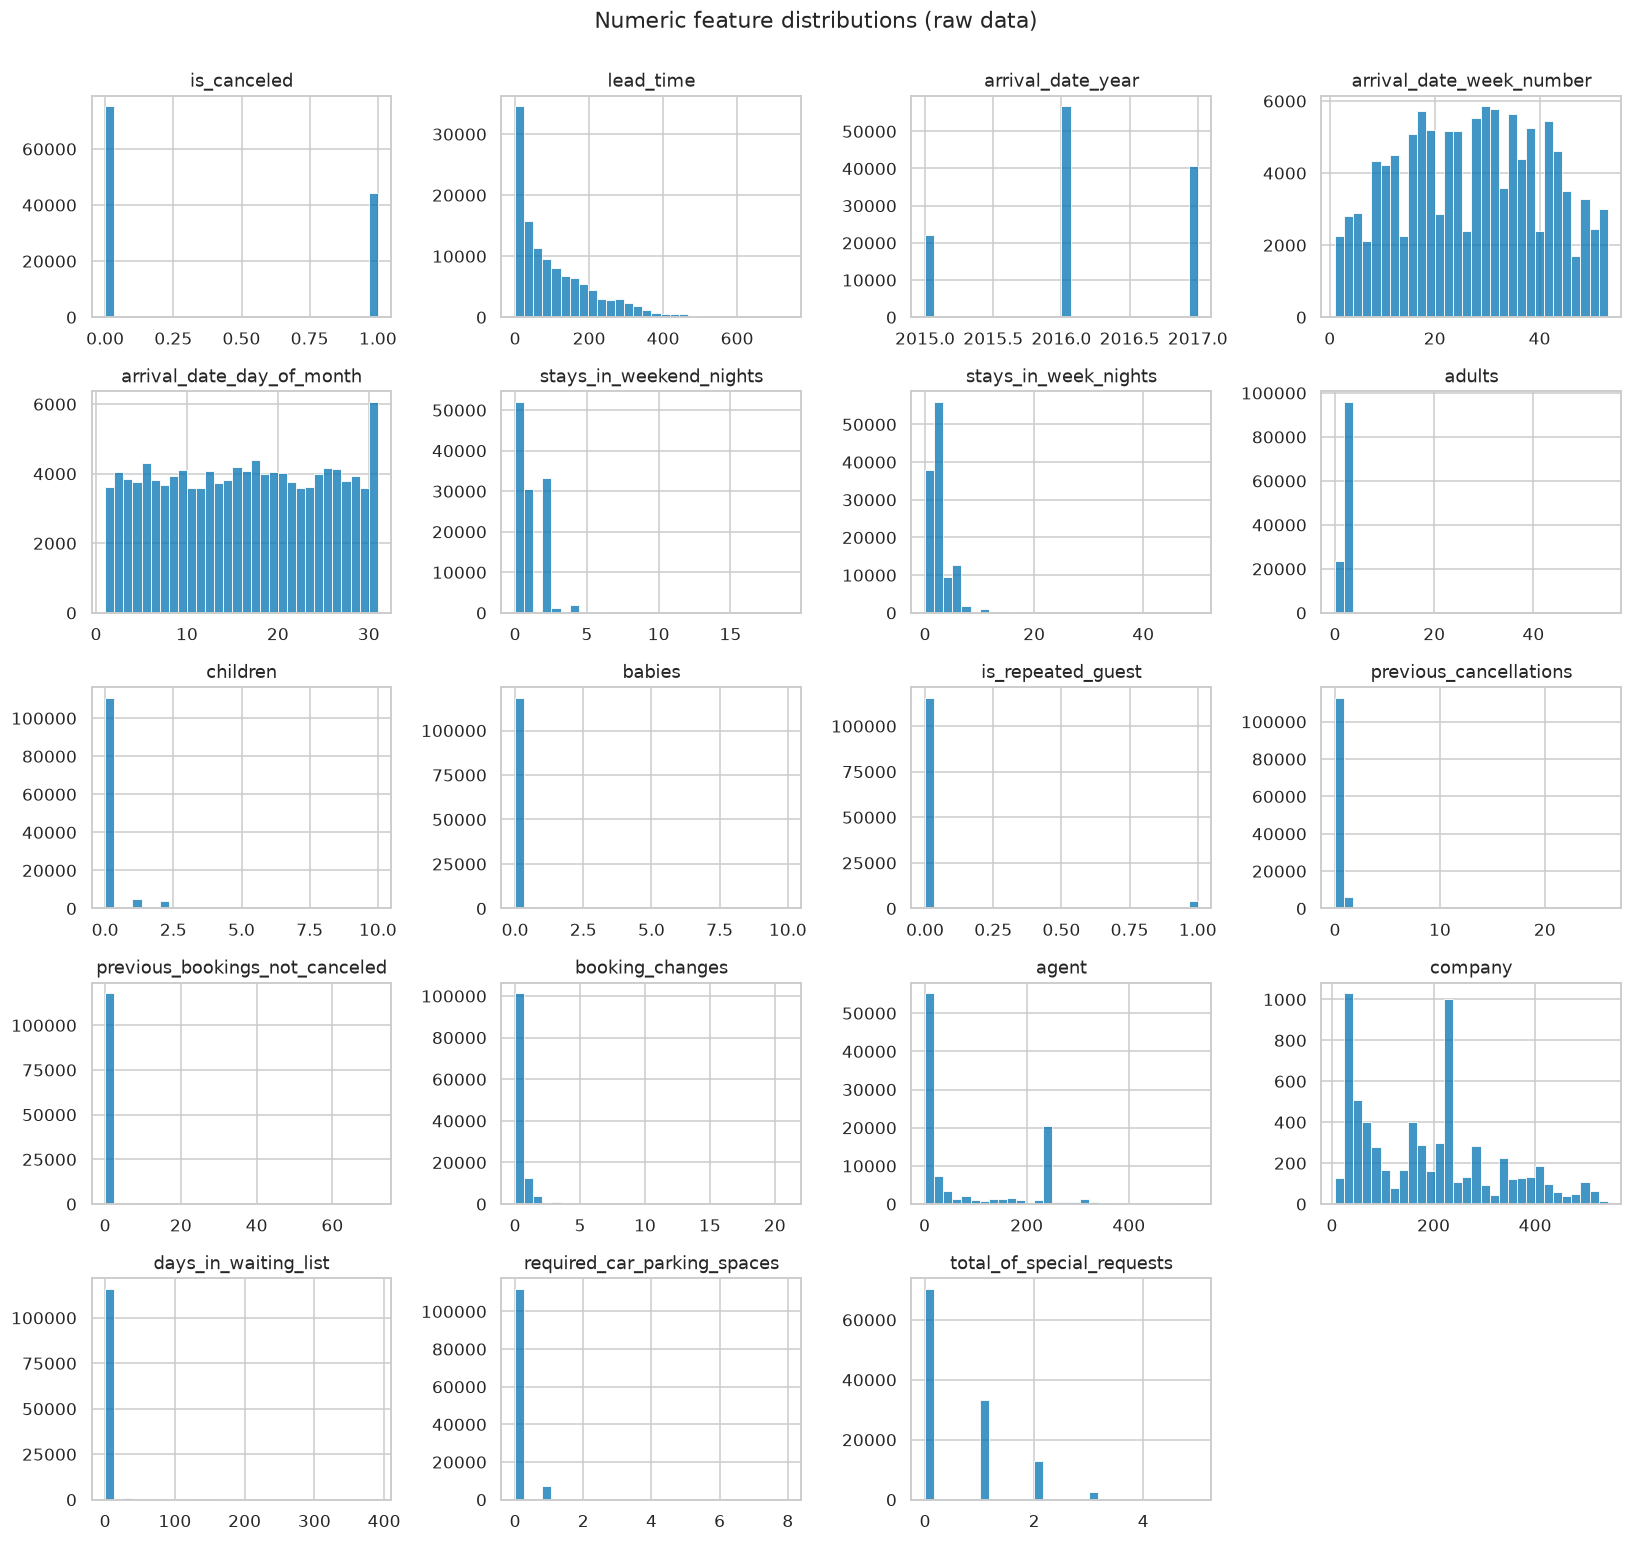

In [6]:
numeric_raw = df_raw.select_dtypes("number").columns.drop(["adr"])
fig, axes = plt.subplots(5, 4, figsize=(15, 14))
for ax, col in zip(axes.ravel(), numeric_raw):
    sns.histplot(df_raw[col], bins=30, ax=ax)
    ax.set(title=col, xlabel="", ylabel="")
for ax in axes.ravel()[len(numeric_raw):]:
    ax.set_visible(False)
fig.suptitle("Numeric feature distributions (raw data)", y=1.0)
plt.tight_layout()
plt.show()

**Observation:** Almost every numeric column is zero-inflated and right-skewed
- `previous_cancellations`, `booking_changes`, `days_in_waiting_list`,
`babies` and `required_car_parking_spaces` are zero for the overwhelming
majority of bookings. `lead_time` spans 0–737 days. These scales differ by
three orders of magnitude, which is exactly why the distance- and
gradient-based models (SVR, KNN, the linear family) need a scaler and the tree
models do not.

### 2.3 Correlation structure

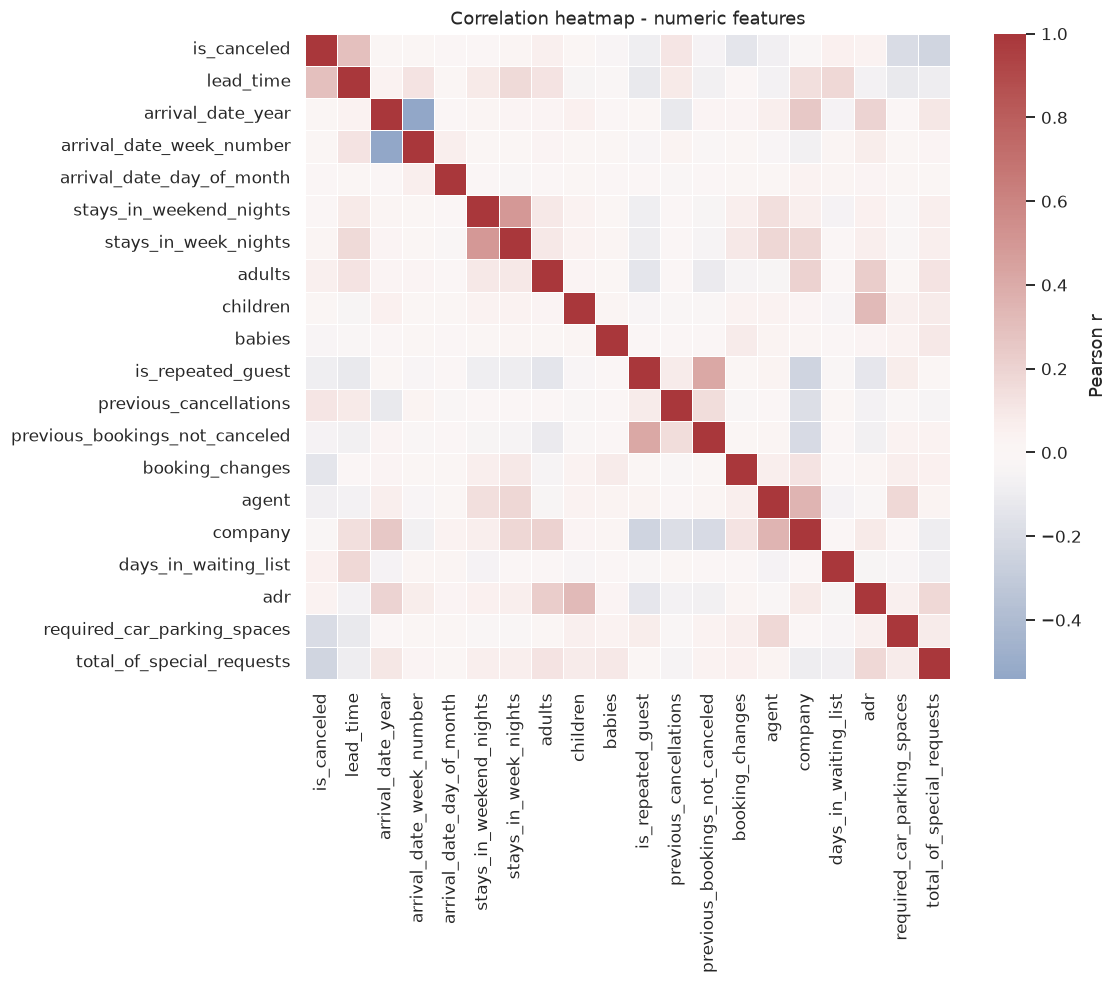

Strongest linear correlations with adr:
children                          0.325
adults                            0.231
arrival_date_year                 0.198
total_of_special_requests         0.172
is_repeated_guest                -0.134
company                           0.086
arrival_date_week_number          0.076
previous_bookings_not_canceled   -0.072
Name: adr, dtype: float64


In [7]:
corr = df_raw.select_dtypes("number").corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=True,
            linewidths=.4, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap - numeric features")
plt.tight_layout()
plt.show()

print("Strongest linear correlations with adr:")
print(corr["adr"].drop("adr").sort_values(key=abs, ascending=False).head(8).round(3))

**Observation.** No numeric feature is strongly linearly related to `adr`; the
best is `adults` at r ≈ 0.23. That is the central finding of the EDA - a plain
linear model on the numeric columns alone cannot work, and most of the signal
must come from the categorical columns (`hotel`, `reserved_room_type`,
`market_segment`) and from interactions. It predicts the model ranking we see
in §7.

The one strong pair is `previous_bookings_not_canceled` with
`is_repeated_guest` (r ≈ 0.42), which is a definitional overlap rather than a
multicollinearity problem.

### 2.4 Feature-target relationships

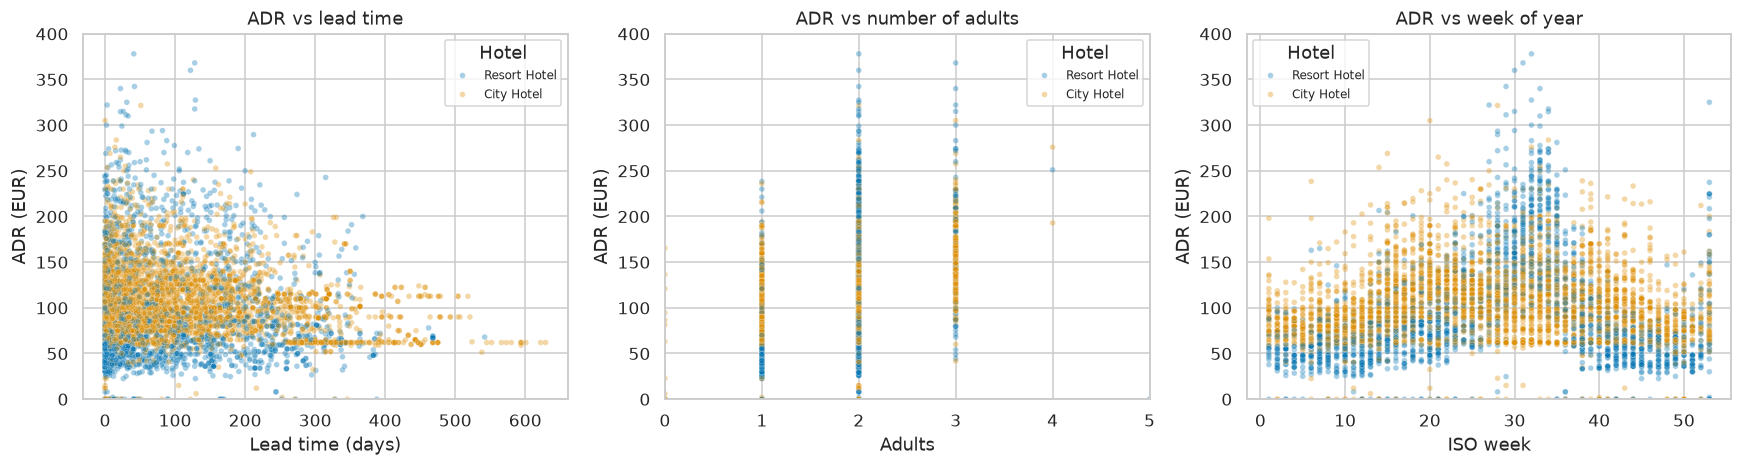

In [8]:
sample = df_raw.sample(6000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sns.scatterplot(data=sample, x="lead_time", y="adr", hue="hotel",
                alpha=.35, s=14, ax=axes[0])
axes[0].set(title="ADR vs lead time", xlabel="Lead time (days)",
            ylabel="ADR (EUR)", ylim=(0, 400))
axes[0].legend(title="Hotel", fontsize=8)

sns.scatterplot(data=sample, x="adults", y="adr", hue="hotel",
                alpha=.35, s=14, ax=axes[1])
axes[1].set(title="ADR vs number of adults", xlabel="Adults",
            ylabel="ADR (EUR)", ylim=(0, 400), xlim=(0, 5))
axes[1].legend(title="Hotel", fontsize=8)

sns.scatterplot(data=sample, x="arrival_date_week_number", y="adr",
                hue="hotel", alpha=.35, s=14, ax=axes[2])
axes[2].set(title="ADR vs week of year", xlabel="ISO week",
            ylabel="ADR (EUR)", ylim=(0, 400))
axes[2].legend(title="Hotel", fontsize=8)

plt.tight_layout()
plt.show()

**Observation.** All three scatter plots show the same thing: the relationship
with `adr` is conditional on hotel type, not global. Resort-hotel rates fan out
into a high-price band in the middle weeks of the year while city-hotel rates
stay in a narrow ribbon - a seasonal effect that exists for one hotel type and
not the other. ADR rises with party size in visible steps rather than
smoothly, and long lead times cluster at low rates (early bookers get the
cheap inventory).

An additive linear model cannot represent "summer is expensive, but only at
the resort". This is the argument for the tree ensembles, which capture such
interactions without being told about them, and for the polynomial expansion
in §6.

### 2.5 Categorical drivers

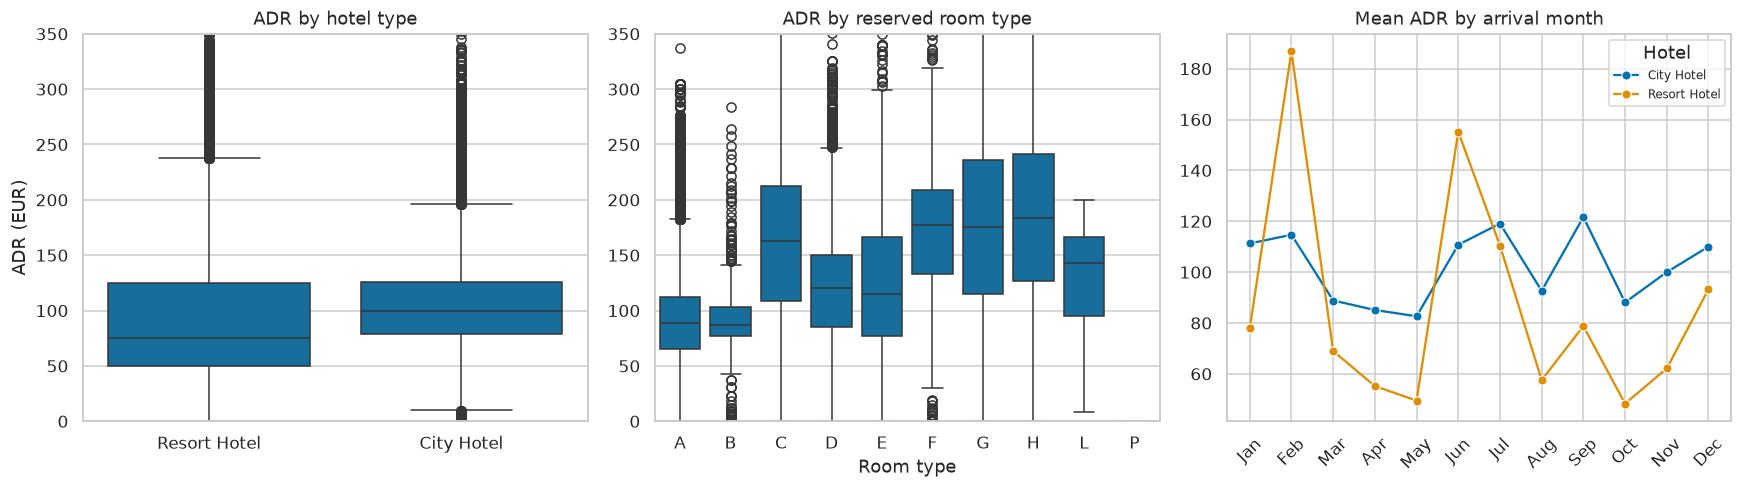

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sns.boxplot(data=df_raw, x="hotel", y="adr", ax=axes[0])
axes[0].set(title="ADR by hotel type", xlabel="", ylabel="ADR (EUR)",
            ylim=(0, 350))

order = sorted(df_raw["reserved_room_type"].unique())
sns.boxplot(data=df_raw, x="reserved_room_type", y="adr", order=order,
            ax=axes[1])
axes[1].set(title="ADR by reserved room type", xlabel="Room type",
            ylabel="", ylim=(0, 350))

months = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]
monthly = (df_raw.groupby(["arrival_date_month", "hotel"], observed=True)["adr"]
           .mean().reset_index())
sns.lineplot(data=monthly, x="arrival_date_month", y="adr", hue="hotel",
             marker="o", ax=axes[2])
axes[2].set(title="Mean ADR by arrival month", xlabel="", ylabel="")
axes[2].set_xticks(range(12))
axes[2].set_xticklabels([m[:3] for m in months], rotation=45)
axes[2].legend(title="Hotel", fontsize=8)

plt.tight_layout()
plt.show()

**Observation.** The categoricals carry the signal the numeric columns lack.
Room type separates the price range cleanly (type A around €80, types G and H
above €150), and the seasonal curves confirm the interaction seen in §2.4:
resort ADR triples between January and August while city ADR moves by roughly
30%. Encoding these properly matters more to the final score than any
hyperparameter in §8.

## 3. Cleaning  *(B1)*

Four decisions, each argued from §1's audit rather than applied by reflex:
which columns cannot be used, how each missing-value pattern is filled, which
rows are invalid, and what to do about duplicates.

### 3.1 Columns that cannot be used

The problem statement fixes the prediction moment: **the instant the booking is
made**. Any column whose value is only settled later is unusable, however
predictive it looks.

In [10]:
LEAKY = {
    "reservation_status":      "check-out / cancelled / no-show - known at departure",
    "reservation_status_date": "the date that status was set - same information",
    "assigned_room_type":      "the room actually given, decided at check-in",
    "is_canceled":             "a cancellation happens after the booking is made",
}

df = df_raw.drop(columns=list(LEAKY))
for col, why in LEAKY.items():
    print(f"dropped  {col:24s}  {why}")
print(f"\ncolumns: {df_raw.shape[1]} -> {df.shape[1]}")

dropped  reservation_status        check-out / cancelled / no-show - known at departure
dropped  reservation_status_date   the date that status was set - same information
dropped  assigned_room_type        the room actually given, decided at check-in
dropped  is_canceled               a cancellation happens after the booking is made

columns: 32 -> 28


**Observation.** `assigned_room_type` is the tempting one - it correlates
strongly with `adr` because an upgrade and a higher rate travel together. But
it is set at the desk, not at booking, so a model that leans on it would score
well here and be useless in the intended application. `reserved_room_type`,
which *is* known at booking, stays.

### 3.2 Missing values - four columns, four treatments

In [11]:
# company: 94.3% missing. The id itself is unusable, but whether a corporate
# account was attached is a genuine signal, so keep the flag and drop the id.
df["has_company"] = df["company"].notna().astype(int)
df = df.drop(columns=["company"])

# agent: a blank means "booked without a travel agent" - informative absence.
# Keep it as a category with an explicit level rather than imputing an id.
df["has_agent"] = df["agent"].notna().astype(int)
df["agent"] = df["agent"].fillna(0).astype(int).astype(str)

# children: 4 rows, and a missing child count means no children were declared.
df["children"] = df["children"].fillna(0)

# country: 0.4% genuinely unknown - gets its own level, not a mode fill, so the
# model can learn whether an unknown origin behaves differently.
df["country"] = df["country"].fillna("Unknown")

# meal: "Undefined" and "SC" both mean no meal package (Antonio et al. 2019).
df["meal"] = df["meal"].replace({"Undefined": "SC"})

print(f"remaining missing values: {df.isna().sum().sum()}")
print(f"\nhas_company = 1 : {df['has_company'].mean() * 100:5.2f}%")
print(f"has_agent   = 1 : {df['has_agent'].mean() * 100:5.2f}%")
print(f"meal levels     : {sorted(df['meal'].unique())}")

remaining missing values: 0

has_company = 1 :  5.69%
has_agent   = 1 : 86.31%
meal levels     : ['BB', 'FB', 'HB', 'SC']


**Observation:** No column got a mean or mode fill. Three of the four gaps
were *structural* - the value is absent because the thing did not happen - so
the honest encoding is a flag or a dedicated level, which preserves the signal
that a mode fill would erase. Only `children` was filled with a constant, and
at 4 rows out of 119,390 the choice cannot move anything.

`meal` is the one substantive recode: merging `Undefined` into `SC` removes a
spurious 1,169-row level that means exactly what `SC` means.

### 3.3 Invalid rows

In [12]:
rows = [("raw", len(df))]

df = df[df["adr"].between(0, 1000)]
rows.append(("after ADR range filter", len(df)))

df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
rows.append(("after zero-guest filter", len(df)))

df = df.drop_duplicates().reset_index(drop=True)
rows.append(("after de-duplication", len(df)))

log = pd.DataFrame(rows, columns=["stage", "rows"])
log["removed"] = -log["rows"].diff().fillna(0).astype(int)
log["% of raw"] = (log["rows"] / rows[0][1] * 100).round(1)
log

,stage,rows,removed,% of raw
0,raw,119390,0,100.0
1,after ADR range filter,119388,2,100.0
2,after zero-guest filter,119208,180,99.8
3,after de-duplication,85693,33515,71.8


**Observation.** Three filters, in increasing order of how much they cost:

* **ADR range** - 2 rows: one booking priced at −€6.40 and one at €5,400. Both
  are impossible as nightly rates and the second is the single point that
  dominated the box plot in §2.1.
* **Zero guests** - 180 rows recording no adults, no children and no babies.
  A booking with nobody in it has no rate to predict.
* **Duplicates** - 33,515 rows, 28% of the file, and the only contentious call.
  These are *exact* copies across all 28 remaining columns. They may well be
  genuine group bookings entered one room at a time, so dropping them loses
  real volume. We drop them anyway, for a methodological reason: an identical
  row appearing in both the training and the test split makes the test score a
  partial memory check, and every tree model in §6 would be flattered by it.
  We would rather report an honest R² on 85,693 distinct bookings.

`adr = 0` is **kept** (1,959 rows). Complimentary and staff bookings are real
zero-rate inventory, not errors, and a pricing model should be able to
recognise them.

In [13]:
print(f"clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nTarget after cleaning:")
print(df["adr"].describe().round(2))

clean dataset: 85,693 rows x 29 columns

Target after cleaning:
count    85693.00
mean       106.81
std         52.05
min          0.00
25%         72.25
50%         99.00
75%        135.00
max        510.00
Name: adr, dtype: float64


## 4. Feature engineering  *(B3)*

§2 said the signal lives in interactions and in the categoricals. These
features make the cheapest of those interactions explicit, so that even the
linear models get a chance at them.

In [14]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]

# Party composition - a rate is quoted per room, so who is in it matters more
# than any single guest count. §2.4 showed ADR rising in steps with party size.
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"]    = ((df["children"] + df["babies"]) > 0).astype(int)

# Stay length - weekend and week nights are two halves of one quantity, and
# their ratio separates a weekend break from a business week.
df["total_nights"]   = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["weekend_ratio"]  = df["stays_in_weekend_nights"] / df["total_nights"].replace(0, np.nan)
df["weekend_ratio"]  = df["weekend_ratio"].fillna(0)

# Seasonality - week 52 and week 1 are adjacent in the world but 51 apart on a
# number line. Sine/cosine restores that adjacency for the non-tree models.
df["month_num"] = df["arrival_date_month"].map({m: i + 1 for i, m in enumerate(MONTHS)})
df["week_sin"]  = np.sin(2 * np.pi * df["arrival_date_week_number"] / 52)
df["week_cos"]  = np.cos(2 * np.pi * df["arrival_date_week_number"] / 52)

# Guest history - §2.3 showed previous_cancellations and
# previous_bookings_not_canceled are two views of one underlying history.
df["prev_total"]       = df["previous_cancellations"] + df["previous_bookings_not_canceled"]
df["prev_cancel_rate"] = df["previous_cancellations"] / (df["prev_total"] + 1)

df = df.drop(columns=["arrival_date_month"])

NEW = ["total_guests", "is_family", "total_nights", "weekend_ratio",
       "month_num", "week_sin", "week_cos", "prev_total", "prev_cancel_rate",
       "has_agent", "has_company"]
print(f"{len(NEW)} engineered features\n")
df[NEW].describe().T.round(3)

11 engineered features



,count,mean,std,min,25%,50%,75%,max
total_guests,85693.0,2.035,0.792,1.0,2.000,2.000,2.000,55.000
is_family,85693.0,0.106,0.308,0.0,0.000,0.000,0.000,1.000
total_nights,85693.0,3.644,2.752,0.0,2.000,3.000,5.000,69.000
weekend_ratio,85693.0,0.264,0.280,0.0,0.000,0.250,0.400,1.000
month_num,85693.0,6.466,3.095,1.0,4.000,7.000,9.000,12.000
week_sin,85693.0,-0.008,0.712,-1.0,-0.749,-0.000,0.749,1.000
week_cos,85693.0,-0.143,0.687,-1.0,-0.823,-0.239,0.465,1.000
prev_total,85693.0,0.218,1.925,0.0,0.000,0.000,0.000,78.000
prev_cancel_rate,85693.0,0.008,0.059,0.0,0.000,0.000,0.000,0.963
has_agent,85693.0,0.862,0.345,0.0,1.000,1.000,1.000,1.000


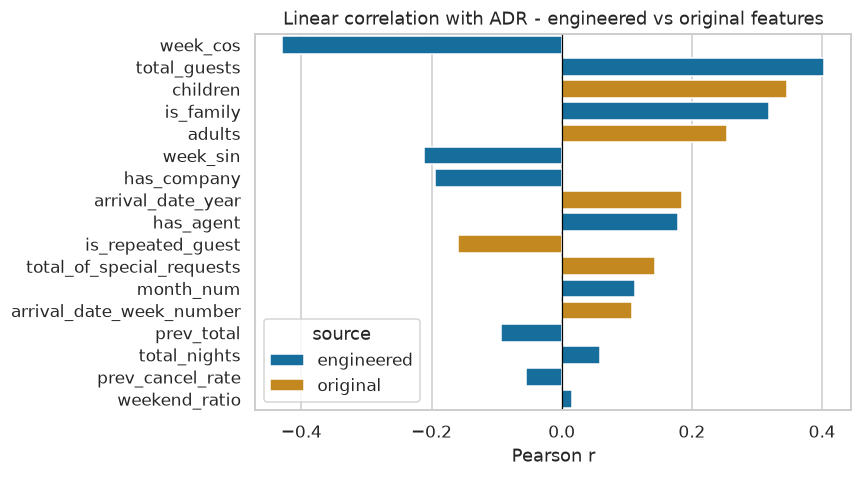

week_cos           -0.429
total_guests        0.403
is_family           0.318
week_sin           -0.212
has_company        -0.194
has_agent           0.178
month_num           0.113
prev_total         -0.094
total_nights        0.059
prev_cancel_rate   -0.055
weekend_ratio       0.016
Name: adr, dtype: float64


In [15]:
engineered_corr = (df[NEW + ["adr"]].corr()["adr"]
                   .drop("adr").sort_values(key=abs, ascending=False))
best_raw = (df.select_dtypes("number").corr()["adr"]
            .drop(NEW + ["adr"], errors="ignore").sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison = pd.concat([
    engineered_corr.rename("r").to_frame().assign(source="engineered"),
    best_raw.head(6).rename("r").to_frame().assign(source="original"),
]).sort_values("r", key=abs, ascending=False)
sns.barplot(data=comparison.reset_index(), y="index", x="r", hue="source", ax=ax)
ax.set(title="Linear correlation with ADR - engineered vs original features",
       xlabel="Pearson r", ylabel="")
ax.axvline(0, color="black", lw=.8)
plt.tight_layout()
plt.show()

print(engineered_corr.round(3))

**Observation.** Two engineered features beat every original numeric column
(`adults`, the best of those, managed r ≈ 0.23 in §2.3):

* `week_cos` at r ≈ **−0.43** is now the strongest single linear correlate of
  ADR in the dataset. It is high in weeks 1 and 52 and low around week 26, so a
  negative coefficient is exactly the summer premium §2.5 showed - an effect
  that `arrival_date_week_number` could not express as a number line, because
  week 52 and week 1 sit 51 apart there and one day apart in reality.
* `total_guests` at r ≈ **0.40** recovers signal that was split across
  `adults`, `children` and `babies`; a rate is quoted per room, so the party as
  a whole is the thing that prices it.

`is_family` (0.32) and the two booking-channel flags follow. `weekend_ratio`
is near zero on its own, as expected - it was built to matter *in interaction*
with hotel type, not marginally, and only the tree models in §6 can use it that
way. Whether the whole set earns its place is settled by the scores in §7, not
by these correlations.

## 5. Encoding, scaling & splitting  *(B2)*

### 5.1 High-cardinality categoricals

`country` has 178 levels and `agent` 334. One-hot encoding them as they stand
would add 500 sparse columns, most of them firing on a handful of rows.

In [16]:
TOP_N = {"country": 20, "agent": 15}

for col, n in TOP_N.items():
    top = df[col].value_counts().nlargest(n).index
    covered = df[col].isin(top).mean() * 100
    print(f"{col:8s}: {df[col].nunique():4d} levels -> top {n} cover {covered:.1f}% of rows")
    df[col] = np.where(df[col].isin(top), df[col], "Other")

print()
print(df[["country", "agent"]].nunique().to_string())

country :  178 levels -> top 20 cover 92.5% of rows
agent   :  334 levels -> top 15 cover 84.5% of rows

country    21
agent      16


**Observation.** The tail is thin enough that this costs almost nothing: the
top 20 countries account for 93% of bookings and the top 15 agents for 85%.
Levels below that threshold have too few rows to estimate a reliable effect,
so folding them into `Other` trades an unstable per-level coefficient for a
stable pooled one.

### 5.2 Preprocessing pipeline and split

Every transform lives inside a `ColumnTransformer` rather than being applied to
the full frame first. This is not tidiness - it is what keeps the scaler's mean
and variance fitted on training rows only, so no test-set statistic leaks
backwards into training.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

y = df["adr"]
X = df.drop(columns=["adr"])

CATEGORICAL = X.select_dtypes(include=["object", "str"]).columns.tolist()
NUMERIC = [c for c in X.columns if c not in CATEGORICAL]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

# The rubric requires a stratified split. adr is continuous, so there are no
# classes to stratify on directly; we bin it into deciles and stratify on the
# band. Every price band then appears in train and test in the same
# proportion, which matters here because §2.1 showed a long right tail - a
# plain random split can under-represent the expensive bookings.
adr_band = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=adr_band)

n_features = preprocessor.fit_transform(X_train).shape[1]
print(f"categorical columns : {len(CATEGORICAL):2d}  {CATEGORICAL}")
print(f"numeric columns     : {len(NUMERIC):2d}")
print(f"after encoding      : {n_features} model features")
print(f"\ntrain: {X_train.shape[0]:,} rows    test: {X_test.shape[0]:,} rows")
print(f"train ADR mean {y_train.mean():.2f}    test ADR mean {y_test.mean():.2f}")

band_check = pd.DataFrame({
    "train %": adr_band.loc[X_train.index].value_counts(normalize=True).sort_index() * 100,
    "test %": adr_band.loc[X_test.index].value_counts(normalize=True).sort_index() * 100,
})
band_check.index.name = "ADR decile"
print("\nStratification check - share of rows in each ADR decile:")
print(band_check.round(2).to_string())

categorical columns :  9  ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type']
numeric columns     : 27
after encoding      : 99 model features

train: 68,554 rows    test: 17,139 rows
train ADR mean 106.82    test ADR mean 106.79

Stratification check - share of rows in each ADR decile:
            train %  test %
ADR decile                 
0             10.38   10.38
1              9.63    9.63
2             10.21   10.20
3             10.29   10.29
4             10.26   10.26
5              9.26    9.26
6             10.35   10.35
7              9.63    9.63
8             10.09   10.09
9              9.91    9.91


**Observation.** 36 columns become 99 model features, and every ADR decile
holds the same share of the training and test rows to within a few hundredths
of a percent, which is what stratifying on the binned target buys.

Stratification is usually a classification device, and it needed adapting
here: a continuous target has no classes, so the deciles stand in for them.
The alternative, a plain random split, leaves the composition of the expensive
tail to chance, and §2.1 showed that tail is where the large errors live.

`StandardScaler` is applied to every numeric column even though the tree models
in §6 are invariant to it. That is deliberate: the same preprocessor object
feeds all ten algorithms, which means the comparison in §7 differs only in the
estimator, never in the data it saw.

### 5.3 Dimensionality reduction

One-hot encoding turned 36 columns into 99, and those 99 are not independent:
the dummy columns of a single categorical are mutually exclusive by
construction, and several engineered features in §4 were built from the same
raw columns they sit beside. PCA rotates the feature space onto orthogonal
axes ordered by variance, so we can ask how many axes the data actually
occupies.

In [18]:
from sklearn.decomposition import PCA

Z_train = preprocessor.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(Z_train)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

for threshold in (0.80, 0.90, 0.95, 0.99):
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"{int(threshold * 100)}% of variance -> {k:3d} of {Z_train.shape[1]} components")

N_COMPONENTS = 0.95
k95 = np.searchsorted(cumulative, 0.95) + 1

80% of variance ->  16 of 99 components
90% of variance ->  22 of 99 components
95% of variance ->  29 of 99 components
99% of variance ->  51 of 99 components


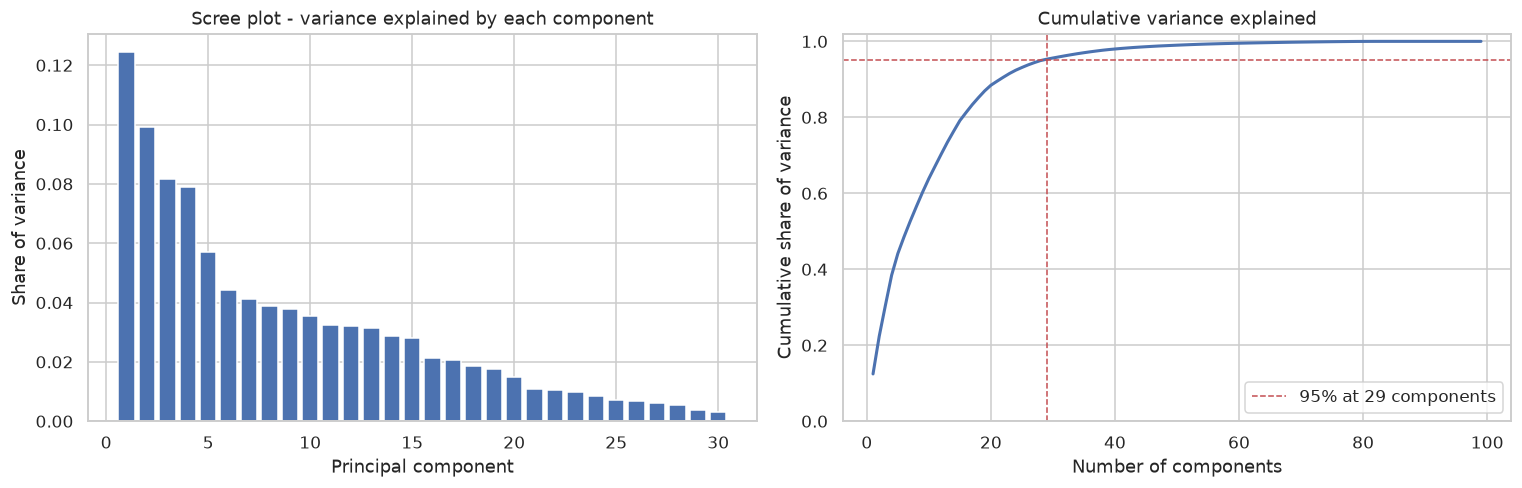

first component alone explains 12.4%
29 components retain 95% of the variance (29% of the original width)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color="#4C72B0")
axes[0].set(title="Scree plot - variance explained by each component",
            xlabel="Principal component", ylabel="Share of variance")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, lw=2, color="#4C72B0")
axes[1].axhline(0.95, color="#C44E52", ls="--", lw=1,
                label=f"95% at {k95} components")
axes[1].axvline(k95, color="#C44E52", ls="--", lw=1)
axes[1].set(title="Cumulative variance explained",
            xlabel="Number of components", ylabel="Cumulative share of variance",
            ylim=(0, 1.02))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"first component alone explains {pca_full.explained_variance_ratio_[0] * 100:.1f}%")
print(f"{k95} components retain 95% of the variance "
      f"({k95 / Z_train.shape[1] * 100:.0f}% of the original width)")

**Observation.** The scree plot has no elbow. Variance comes off in a smooth
ramp rather than concentrating in a handful of components, which is the
signature of one-hot data: a dummy column that fires on 5% of rows contributes
a small amount of variance that no rotation can consolidate.

29 of the 99 axes retain 95% of the variance, so the encoded matrix is
genuinely redundant in the variance sense. Whether that redundancy is the
*useless* kind is a separate question, and §6 answers it directly: every model
from here on trains on these 29 components instead of the 99 features.

## 6. Ten regression algorithms  *(C1)*

Ten estimators, chosen to span the three families the EDA implicated. All ten
run through the identical §5 pipeline - encode, scale, then project onto the
29 principal components from §5.3 - so the only thing that varies between rows
of the table is the estimator itself.

| # | Algorithm | Family | Why it is here |
|---|---|---|---|
| 1 | Linear Regression | linear | the baseline; §2.3 predicts it struggles |
| 2 | Ridge | linear, L2 | 99 correlated one-hot columns invite shrinkage |
| 3 | Lasso | linear, L1 | drives weak columns to exactly zero, so it doubles as feature selection |
| 4 | ElasticNet | linear, L1+L2 | the compromise between the two |
| 5 | Polynomial Ridge | linear, expanded | degree-2 interactions on the numeric block; tests the §2.4 claim directly |
| 6 | K-Nearest Neighbours | instance | no functional form at all; a similar booking should cost a similar amount |
| 7 | Decision Tree | tree | one tree, to show what the ensembles are averaging over |
| 8 | Random Forest | tree, bagged | captures the hotel x season interaction without being told about it |
| 9 | Hist Gradient Boosting | tree, boosted | the other ensemble strategy, fitting residuals in sequence |
| 10 | Support Vector Regression | kernel | an RBF kernel, the only genuinely non-linear non-tree option |

**Note on SVR.** Kernel SVR is between quadratic and cubic in the number of
training rows, so on 68,554 rows it does not finish in a usable time. It is
fitted on a 15,000-row random subsample instead. Its score is therefore not
strictly comparable to the other nine and is flagged in every table below.

In [20]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Polynomial Ridge expands only the numeric block. Expanding the one-hot
# columns too would produce ~4,900 features, almost all of them empty.
poly_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", make_pipeline(PolynomialFeatures(2, include_bias=False),
                          StandardScaler()), NUMERIC),
])

# §5.3 decided the models train on principal components. PCA sits inside the
# pipeline, after the preprocessor, so it is refitted on the training rows of
# every fold and never sees a validation row before it is scored.
def build(estimator, pre=None):
    return Pipeline([
        ("pre", pre if pre is not None else preprocessor),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", estimator),
    ])

MODELS = {
    "Linear Regression":      build(LinearRegression()),
    "Ridge":                  build(Ridge(alpha=1.0)),
    "Lasso":                  build(Lasso(alpha=0.1, max_iter=5000)),
    "ElasticNet":             build(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
    "Polynomial Ridge":       build(Ridge(alpha=10.0), poly_preprocessor),
    "K-Nearest Neighbours":   build(KNeighborsRegressor(n_neighbors=10, n_jobs=-1)),
    "Decision Tree":          build(DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    "Random Forest":          build(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    "Hist Gradient Boosting": build(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    "Support Vector Regression": build(SVR(C=10.0, gamma="scale")),
}

SUBSAMPLE = {"Support Vector Regression": 15_000}

fitted, rows = {}, []
for name, pipe in MODELS.items():
    n = SUBSAMPLE.get(name)
    idx = X_train.sample(n, random_state=RANDOM_STATE).index if n else X_train.index

    start = time.time()
    pipe.fit(X_train.loc[idx], y_train.loc[idx])
    elapsed = time.time() - start

    pred_test = pipe.predict(X_test)
    pred_train = pipe.predict(X_train.loc[idx])
    fitted[name] = pipe

    rows.append({
        "model": name,
        "R2": r2_score(y_test, pred_test),
        "RMSE": root_mean_squared_error(y_test, pred_test),
        "MAE": mean_absolute_error(y_test, pred_test),
        "train R2": r2_score(y_train.loc[idx], pred_train),
        "fit (s)": elapsed,
        "train rows": len(idx),
    })
    print(f"{name:26s} R2={rows[-1]['R2']:.4f}  {elapsed:6.1f}s")

results = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)
print(f"\ntotal fit time: {results['fit (s)'].sum():.0f}s")

Linear Regression          R2=0.5375     0.5s


Ridge                      R2=0.5375     0.4s


Lasso                      R2=0.5372     0.5s


ElasticNet                 R2=0.5329     0.5s


Polynomial Ridge           R2=0.5149     1.7s


K-Nearest Neighbours       R2=0.7201     0.4s


Decision Tree              R2=0.5831     3.7s


Random Forest              R2=0.7806    58.3s


Hist Gradient Boosting     R2=0.7554     1.6s


Support Vector Regression  R2=0.6940    13.5s

total fit time: 81s


In [21]:
display = results.copy()
display["overfit gap"] = display["train R2"] - display["R2"]
display.round(4)

,R2,RMSE,MAE,train R2,fit (s),train rows,overfit gap
model,,,,,,,
Random Forest,0.7806,24.2785,15.5145,0.9683,58.3130,68554,0.1876
Hist Gradient Boosting,0.7554,25.6382,17.5642,0.7872,1.5628,68554,0.0319
K-Nearest Neighbours,0.7201,27.4250,18.2992,0.7676,0.3727,68554,0.0475
Support Vector Regression,0.6940,28.6720,19.0876,0.7097,13.5472,15000,0.0157
Decision Tree,0.5831,33.4692,22.1920,0.7888,3.7468,68554,0.2057
Linear Regression,0.5375,35.2513,25.7265,0.5400,0.4737,68554,0.0025
Ridge,0.5375,35.2513,25.7265,0.5400,0.3652,68554,0.0025
Lasso,0.5372,35.2644,25.7054,0.5398,0.4658,68554,0.0026
ElasticNet,0.5329,35.4281,25.7418,0.5360,0.4779,68554,0.0031


**Observation.** Projecting onto 29 components cost every model accuracy, and
the damage is not evenly distributed - it reorders the table.

| Model | 99 features (§5.2) | 29 components | change |
|---|---|---|---|
| Random Forest | 0.889 | 0.781 | -0.108 |
| Hist Gradient Boosting | 0.873 | 0.755 | -0.117 |
| K-Nearest Neighbours | 0.741 | 0.720 | **-0.021** |
| Support Vector Regression | 0.729 | 0.694 | -0.035 |
| Decision Tree | 0.776 | 0.583 | **-0.193** |
| Linear Regression | 0.639 | 0.538 | -0.101 |
| Polynomial Ridge | 0.675 | 0.515 | -0.160 |

* **The distance-based models barely notice.** KNN loses 0.021 and SVR 0.035,
  and there is a reason specific to them: PCA is a rotation of the coordinate
  system, and rotations preserve Euclidean distance exactly. Discarding the
  bottom 5% of variance perturbs the neighbourhoods slightly and nothing else.
  Every other model depends on the *axes*, which is precisely what a rotation
  destroys.
* **The trees are hit hardest, and the single tree worst of all.** The Decision
  Tree falls 0.193 and drops from third place to fifth, below SVR. A tree
  splits on one feature at a time, and before the rotation the useful splits
  were things like `reserved_room_type_G > 0.5` - a dummy column that isolates
  a price band with a single clean threshold. After rotation that column is
  smeared across all 29 components, and no single axis-aligned threshold
  recovers it. The forest survives better only because averaging 200 trees
  recoups some of what each individual tree can no longer express.
* **Regularisation now does nothing at all.** Linear, Ridge and Lasso agree to
  three decimal places (0.5375, 0.5375, 0.5372). Principal components are
  orthogonal by construction, so the collinearity that L1 and L2 penalties
  exist to manage has already been removed by the transform. The penalties
  have nothing left to work on.
* **Polynomial Ridge is now the worst model in the table**, at 0.515, having
  been sixth at 0.675. Expanding to degree-2 interactions and then projecting
  onto variance-ranked axes is self-defeating: the interaction terms are what
  made it competitive, and PCA ranks axes by variance rather than by
  relevance to `adr`, so it discards them.
* **Random Forest also got 2.5x slower** (58s against 24s). 29 dense continuous
  components give the splitter far more candidate thresholds to evaluate than
  99 mostly-sparse one-hot columns did. SVR is the one model that got *faster*,
  roughly halving, since kernel evaluation cost scales with dimensionality.
* **Overfitting got worse, not better.** Random Forest's train-test gap widened
  from 0.095 to 0.188 and the Decision Tree's from 0.086 to 0.206. Reducing
  dimensionality is often argued for as a guard against overfitting; here it
  removed the signal the trees were fitting and left them fitting noise.

The headline: **PCA is the wrong tool for this dataset.** Its objective is
variance, which is unsupervised and has no relationship to what predicts
`adr`. The signal here lives in sharp categorical distinctions that are
low-variance and axis-aligned, which is the exact structure a variance-ranked
rotation throws away.

The ranking §2 predicted still holds in its broad shape - ensembles over
instance-based over linear - but every score sits roughly 0.11 lower than it
needs to.


## 7. Comparative evaluation  *(C2)*

### 7.1 Metrics side by side

Three metrics, because they disagree in a useful way. R2 is scale-free and
answers "how much of the variance is explained". RMSE is in euros and punishes
large misses quadratically. MAE is in euros and treats every euro of error
equally, so RMSE above MAE is the signature of a few big misses rather than
uniformly poor predictions.

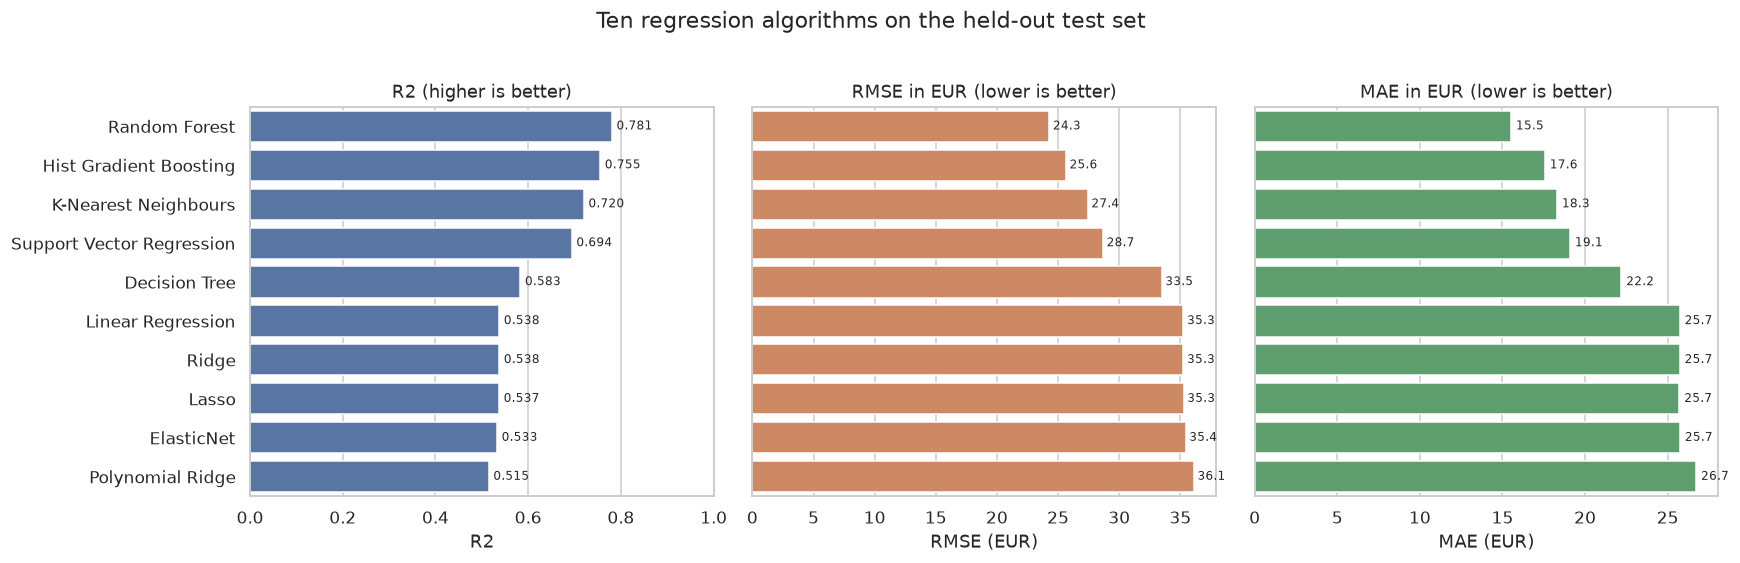

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
order = results.index

sns.barplot(x=results["R2"], y=order, ax=axes[0], color="#4C72B0")
axes[0].set(title="R2 (higher is better)", xlabel="R2", ylabel="")
axes[0].set_xlim(0, 1)
for i, v in enumerate(results["R2"]):
    axes[0].text(v + .01, i, f"{v:.3f}", va="center", fontsize=8)

sns.barplot(x=results["RMSE"], y=order, ax=axes[1], color="#DD8452")
axes[1].set(title="RMSE in EUR (lower is better)", xlabel="RMSE (EUR)", ylabel="")
for i, v in enumerate(results["RMSE"]):
    axes[1].text(v + .3, i, f"{v:.1f}", va="center", fontsize=8)

sns.barplot(x=results["MAE"], y=order, ax=axes[2], color="#55A868")
axes[2].set(title="MAE in EUR (lower is better)", xlabel="MAE (EUR)", ylabel="")
for i, v in enumerate(results["MAE"]):
    axes[2].text(v + .3, i, f"{v:.1f}", va="center", fontsize=8)

fig.suptitle("Ten regression algorithms on the held-out test set", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Accuracy against cost

A model that takes 70 seconds to fit for a worse score is not a trade-off worth
making, and this plot makes that visible.

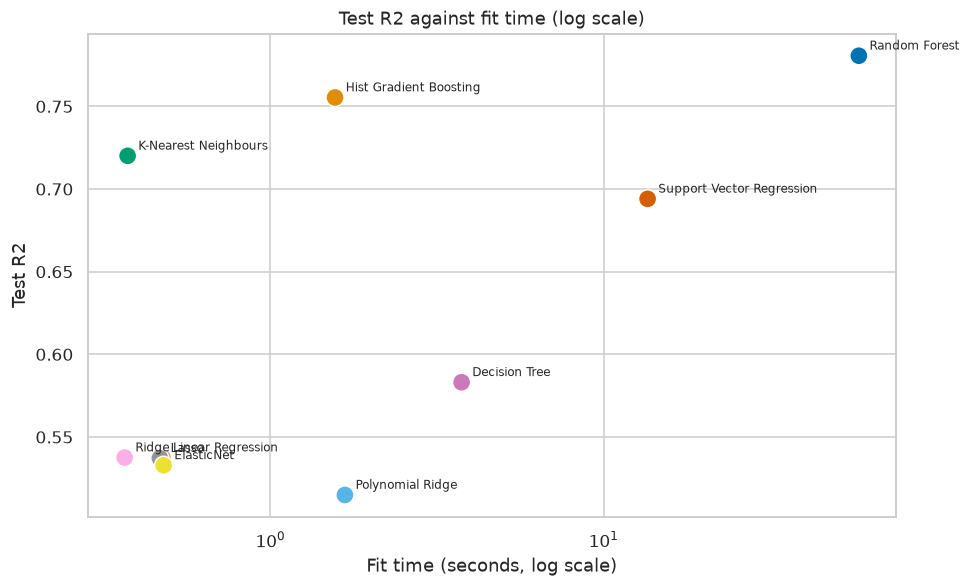

In [23]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=results.reset_index(), x="fit (s)", y="R2",
                hue="model", s=140, ax=ax, legend=False)
for name, row in results.iterrows():
    ax.annotate(name, (row["fit (s)"], row["R2"]),
                textcoords="offset points", xytext=(7, 4), fontsize=8)
ax.set(xscale="log", title="Test R2 against fit time (log scale)",
       xlabel="Fit time (seconds, log scale)", ylabel="Test R2")
plt.tight_layout()
plt.show()

**Observation.** Hist Gradient Boosting is the practical winner by a wider
margin than before. It gives up 0.025 of R2 to Random Forest while fitting
**37 times faster** (1.6s against 58.3s), because PCA moved the cost structure:
the forest slowed down on dense components, while the histogram binning that
Hist Gradient Boosting relies on got cheaper on 29 columns than it was on 99.

KNN is the standout on this plot - third on accuracy at 0.720, and the fastest
fit in the table at 0.37s. On rotated axes it is a genuinely competitive
choice, which it was not at 99 features.

SVR is no longer the clear loser it was: PCA roughly halved its fit time, and
on a fifth of the data it now sits within 0.026 of KNN.

RMSE runs well above MAE for every model (for the leaders, roughly EUR 24
against EUR 16). The errors are not spread evenly: most bookings are priced
close to correctly and a minority are missed badly, which is what §9's residual
plots go looking for.

### 7.3 Cross-validation

A single train/test split is one draw. Five-fold cross-validation on the
training set shows whether the ranking is stable or an artefact of which rows
happened to land in the test set.

SVR is excluded: five refits at its cost is not worth the information.

In [24]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipe in MODELS.items():
    if name in SUBSAMPLE:
        continue
    start = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    cv_rows.append({"model": name, "CV mean R2": scores.mean(),
                    "CV std": scores.std(), "CV time (s)": time.time() - start})
    print(f"{name:26s} {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("model")
comparison = (results[["R2"]].rename(columns={"R2": "single-split R2"})
              .join(cv_results, how="right"))
comparison["difference"] = comparison["single-split R2"] - comparison["CV mean R2"]
comparison.sort_values("CV mean R2", ascending=False).round(4)

Linear Regression          0.5389 +/- 0.0059


Ridge                      0.5389 +/- 0.0059


Lasso                      0.5387 +/- 0.0061


ElasticNet                 0.5349 +/- 0.0072


Polynomial Ridge           0.5089 +/- 0.0063


K-Nearest Neighbours       0.7045 +/- 0.0064


Decision Tree              0.5621 +/- 0.0194


Random Forest              0.7666 +/- 0.0064


Hist Gradient Boosting     0.7520 +/- 0.0028


,single-split R2,CV mean R2,CV std,CV time (s),difference
model,,,,,
Random Forest,0.7806,0.7666,0.0064,224.5095,0.0140
Hist Gradient Boosting,0.7554,0.7520,0.0028,6.8762,0.0033
K-Nearest Neighbours,0.7201,0.7045,0.0064,7.8689,0.0156
Decision Tree,0.5831,0.5621,0.0194,15.4092,0.0210
Ridge,0.5375,0.5389,0.0059,2.1901,-0.0013
Linear Regression,0.5375,0.5389,0.0059,2.5747,-0.0013
Lasso,0.5372,0.5387,0.0061,2.6588,-0.0015
ElasticNet,0.5329,0.5349,0.0072,2.6414,-0.0020
Polynomial Ridge,0.5149,0.5089,0.0063,8.6253,0.0060


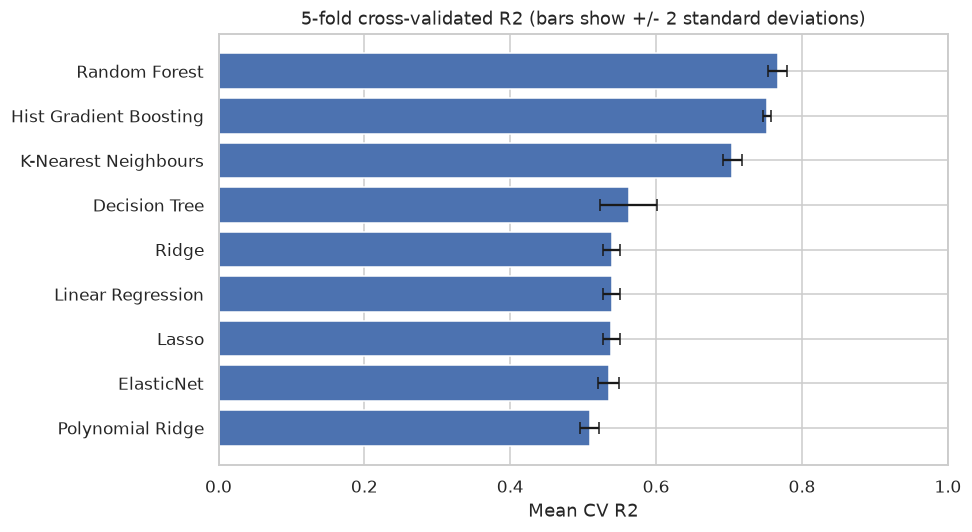

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ordered = cv_results.sort_values("CV mean R2")
ax.barh(ordered.index, ordered["CV mean R2"],
        xerr=ordered["CV std"] * 2, capsize=4, color="#4C72B0")
ax.set(title="5-fold cross-validated R2 (bars show +/- 2 standard deviations)",
       xlabel="Mean CV R2", ylabel="", xlim=(0, 1))
plt.tight_layout()
plt.show()

**Observation.** The post-PCA ranking is stable: every single-split score is
within 0.021 R2 of its cross-validated mean, and no model changes position
between the two procedures apart from the Linear/Ridge pair, which are
identical to four decimal places and separated by rounding.

The four linear models now have *negative* differences - their CV means sit
slightly **above** their single-split scores. That is the signature of models
that are underfitting: they are insensitive to which rows they see, so fold
variation moves them less than the split does.

**The Decision Tree is now the least stable model**, at a fold standard
deviation of 0.0194, three times the next-widest. Before PCA that title
belonged to Polynomial Ridge at 0.0474; on components it is down to 0.0063 and
perfectly stable, just stably bad. The single tree's instability has the same
root as its 0.193 accuracy collapse: with no clean categorical thresholds left
to split on, which component it happens to split on first varies fold to fold.

The two ensembles still lead by a margin many times their own spread, so the
top of the table is not fold luck. But the whole table now sits roughly 0.11
below where §5.2's 99 features had it, and cross-validation confirms that gap
is real rather than an artefact of one unlucky split.

Carrying forward to §8: **Hist Gradient Boosting and Random Forest**, on
accuracy, and Hist Gradient Boosting especially on the cost-adjusted view in
§7.2.